IMPORT AND CONFIG

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

#Config
DATASET_PATH = "./FoodTest1_224"
BATCH_SIZE = 64
EPOCHS = 40
NUM_CLASSES = 40
MODEL_PATH = "food_model.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


TRANSFORM

In [ ]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 3.0)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.25),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

#For validation set
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

DATASET

In [72]:
from torch.utils.data import Subset
#Load the master dataset
master_dataset = datasets.ImageFolder(DATASET_PATH)
total_count = len(master_dataset)

#Do 70/15/15 split for sets
train_size = int(0.7 * total_count)
val_size = int(0.15 * total_count)
test_size = total_count - train_size - val_size

#Generate consistent indices
indices = torch.randperm(total_count).tolist()
train_idx = indices[:train_size]
val_idx = indices[train_size:train_size + val_size]
test_idx = indices[train_size + val_size:]

#Use the wrapper to apply transforms
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

#Create final datasets for training, validation and test
train_dataset = ApplyTransform(Subset(master_dataset, train_idx), transform=train_transform)
val_dataset   = ApplyTransform(Subset(master_dataset, val_idx),   transform=val_transform)
test_dataset  = ApplyTransform(Subset(master_dataset, test_idx),  transform=train_transform)

#Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"Total: {total_count} | Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


Total: 1994 | Train: 1395 | Val: 299 | Test: 300


COMPUTE CLASS WEIGHTS

In [73]:
from collections import Counter
import torch

# Get class counts
targets = [label for _, label in train_dataset]
class_counts = Counter(targets)

num_classes = len(class_counts)
total_samples = sum(class_counts.values())

# Inverse frequency weighting
class_weights = []
for i in range(num_classes):
    class_weights.append(total_samples / (num_classes * class_counts[i]))

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

LOAD MODELS

In [ ]:
def get_model(model_name, num_classes):
    
    if model_name == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # Freeze everything
        for param in model.parameters():
            param.requires_grad = False

        # Unfreeze deeper layers
        for name, param in model.named_parameters():
            if "layer3" in name or "layer4" in name:
                param.requires_grad = True

        model.fc = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(model.fc.in_features, num_classes)
        )

        optimizer = torch.optim.Adam([
            {"params": model.layer3.parameters(), "lr": 1e-5},
            {"params": model.layer4.parameters(), "lr": 1e-5},
            {"params": model.fc.parameters(), "lr": 1e-4}
        ])

    elif model_name == "mobilenetv2":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

        # Freeze early layers
        for param in model.features[:10].parameters():
            param.requires_grad = False

        # Keep later layers trainable
        for param in model.features[10:].parameters():
            param.requires_grad = True

        model.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(model.last_channel, num_classes)
        )

        optimizer = torch.optim.Adam([
            {"params": model.features[10:].parameters(), "lr": 1e-5},
            {"params": model.classifier.parameters(), "lr": 1e-4}
        ])

    else:
        raise ValueError("Invalid model")

    return model.to(device), optimizer

TRAINING SETUP

In [ ]:
model_name = "resnet50"  

model, param_groups = get_model(model_name, num_classes)

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1   # ← small upgrade
)
optimizer = torch.optim.Adam(param_groups)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.3, patience=2
)


def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)

    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)

        inputs, targets_a, targets_b, lam = mixup_data(inputs, targets)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)

    acc = 100 * correct / total
    return running_loss / len(loader), acc


TRAINING LOOP

In [ ]:
num_epochs = 40
best_val_loss = float('inf')
patience = 7
counter = 0

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

Epoch 1
Train Loss: 3.6813
Val Loss: 3.6256 | Val Acc: 6.69%
Epoch 2
Train Loss: 3.5734
Val Loss: 3.5388 | Val Acc: 13.38%
Epoch 3
Train Loss: 3.4728
Val Loss: 3.4410 | Val Acc: 23.08%
Epoch 4
Train Loss: 3.3599
Val Loss: 3.3177 | Val Acc: 33.44%
Epoch 5
Train Loss: 3.2129
Val Loss: 3.1900 | Val Acc: 42.81%
Epoch 6
Train Loss: 3.0351
Val Loss: 2.9927 | Val Acc: 51.84%
Epoch 7
Train Loss: 2.7614
Val Loss: 2.7068 | Val Acc: 58.86%
Epoch 8
Train Loss: 2.5301
Val Loss: 2.4933 | Val Acc: 60.54%
Epoch 9
Train Loss: 2.2865
Val Loss: 2.1691 | Val Acc: 69.57%
Epoch 10
Train Loss: 2.0639
Val Loss: 1.9186 | Val Acc: 70.90%
Epoch 11
Train Loss: 1.9940
Val Loss: 1.7895 | Val Acc: 69.23%
Epoch 12
Train Loss: 1.7405
Val Loss: 1.6153 | Val Acc: 70.23%
Epoch 13
Train Loss: 1.4460
Val Loss: 1.4420 | Val Acc: 71.24%
Epoch 14
Train Loss: 1.4494
Val Loss: 1.3559 | Val Acc: 73.24%
Epoch 15
Train Loss: 1.3520
Val Loss: 1.1878 | Val Acc: 74.92%
Epoch 16
Train Loss: 1.3288
Val Loss: 1.1803 | Val Acc: 74.92%
Ep

SAVE MODEL

In [ ]:
torch.save(model.state_dict(), f"best_{model_name}.pth")


Model saved to food_model.pth


TEST SET EVALUATION

In [77]:
model.load_state_dict(torch.load("best_model.pth"))

test_loss, test_acc = evaluate(model, test_loader, criterion)

print(f"Test Accuracy: {test_acc:.2f}%")

C:\Users\sharw\AppData\Local\Temp\ipykernel_22228\3302743488.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model.pth"))


Test Accuracy: 79.33%


PER CLASS ACCURACY

In [78]:
def per_class_accuracy(model, loader, classes):
    model.eval()
    correct = [0] * len(classes)
    total = [0] * len(classes)

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)

            _, preds = torch.max(outputs, 1)

            for i in range(len(targets)):
                label = targets[i]
                total[label] += 1
                if preds[i] == label:
                    correct[label] += 1

    for i, cls in enumerate(classes):
        acc = 100 * correct[i] / total[i] if total[i] > 0 else 0
        print(f"{cls}: {acc:.2f}%")

DEVELOP CONFUSION MATRIX

C:\Users\sharw\AppData\Local\Temp\ipykernel_22228\1894521308.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Gathering predictions...


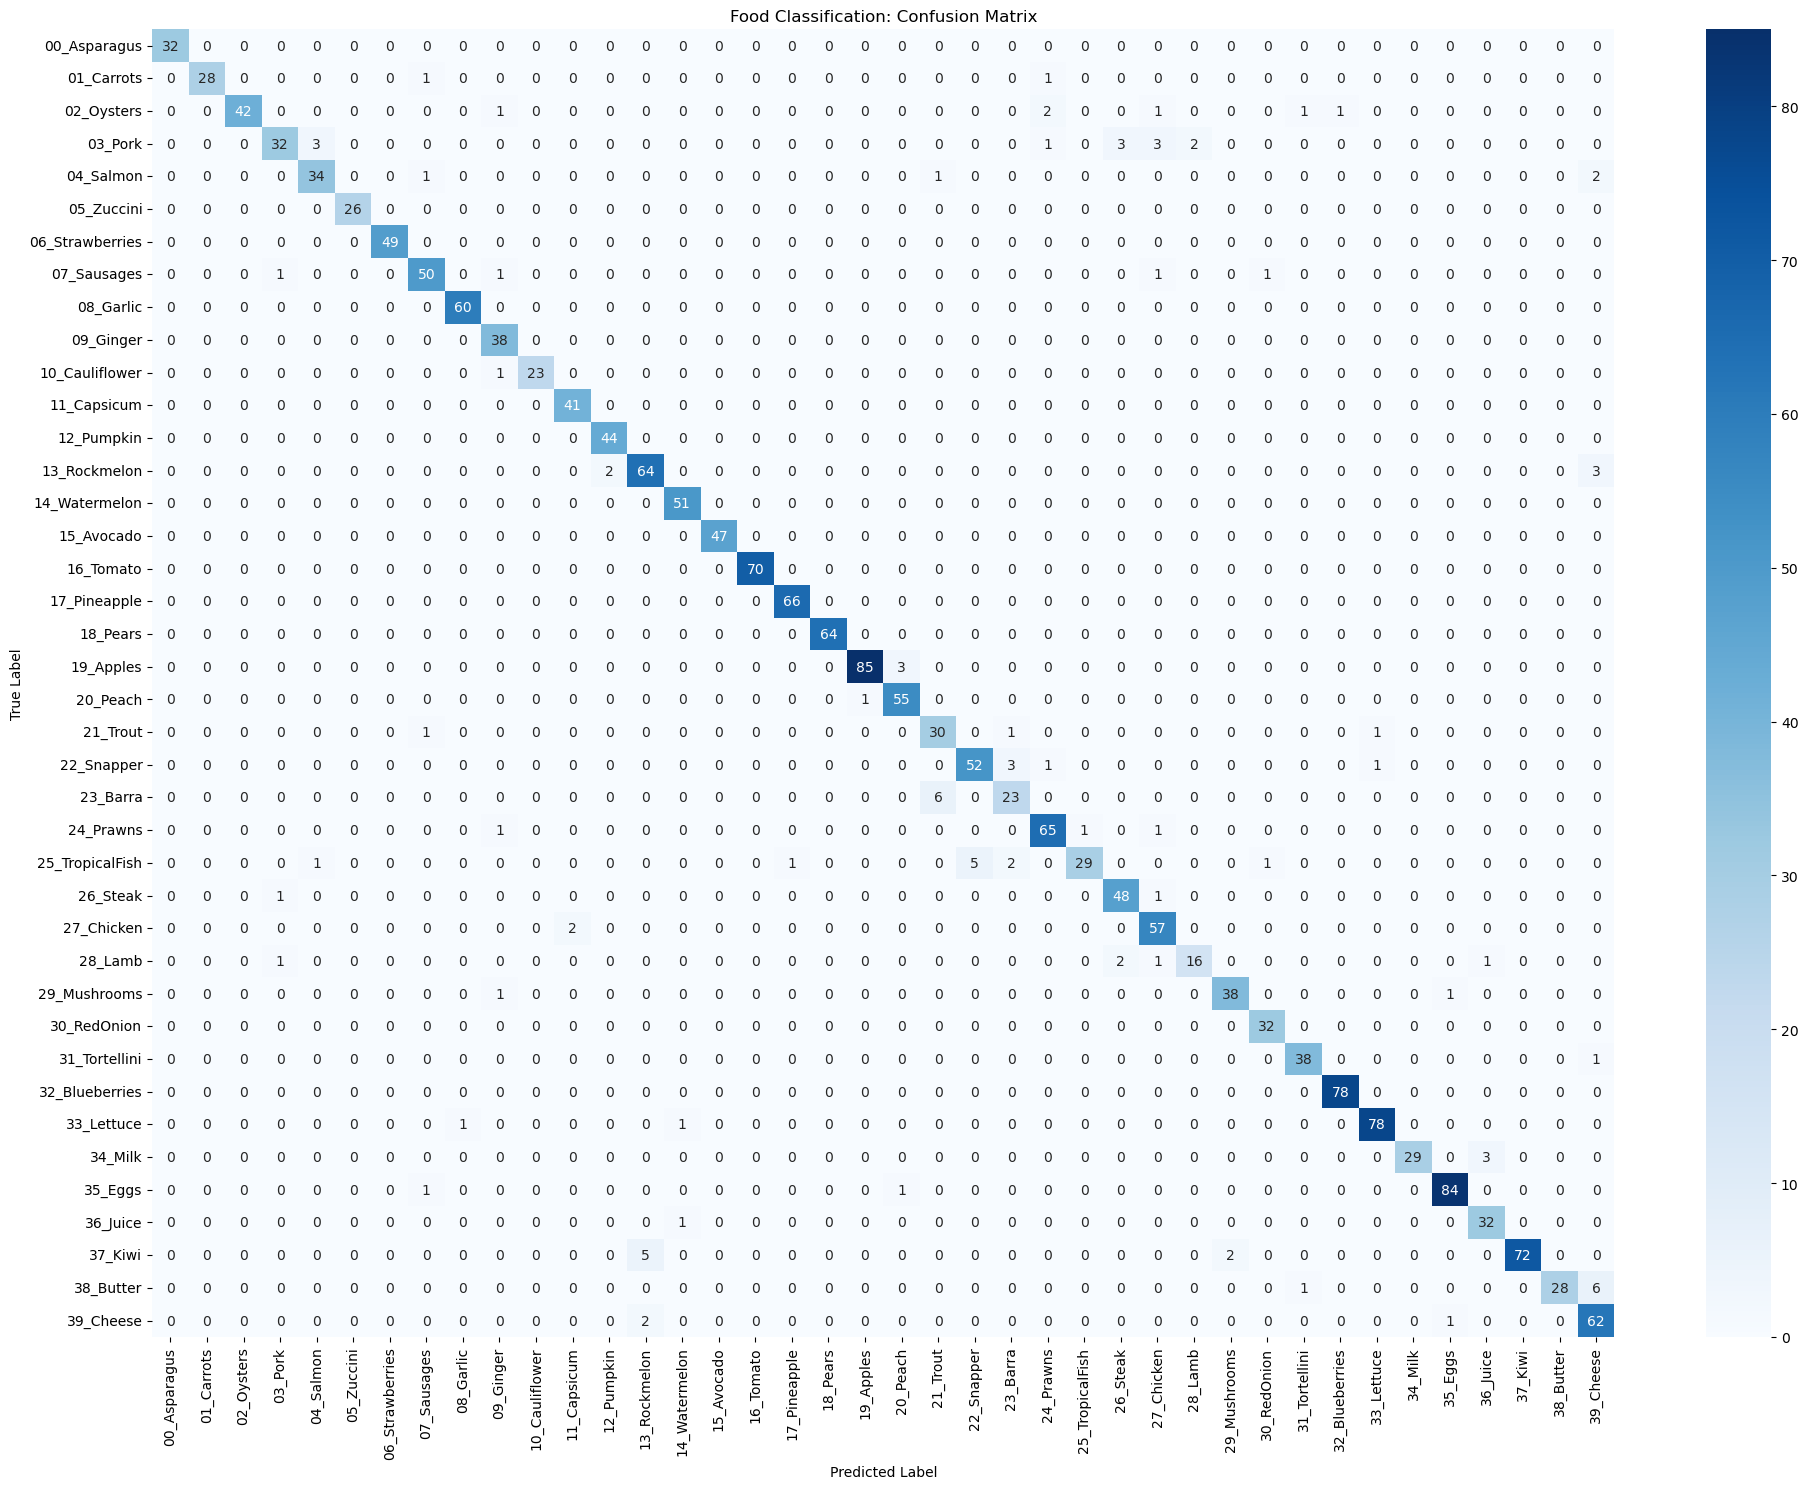

Confusion matrix saved as 'confusion_matrix.png'


In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def generate_confusion_matrix(dataset_path, model_path="food_model.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    #Load Model Architecture
    model = models.resnet50(weights=None)
    model.fc = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(2048, 40)
    )


    #Load the weights 
    try:
        checkpoint = torch.load(model_path, map_location=device)
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)
    except FileNotFoundError:
        print(f"Error: Could not find {model_path}")
        return
    
    model = model.to(device).eval()

    #Prepare Data
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    dataset = datasets.ImageFolder(dataset_path, transform=test_transform)
    loader = DataLoader(dataset, batch_size=32, shuffle=False)

    all_preds = []
    all_labels = []

    #Collect Predictions
    print("Gathering predictions...")
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    #Create and Plot Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(20, 15))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=dataset.classes, yticklabels=dataset.classes)
    
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Food Classification: Confusion Matrix')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    plt.savefig('confusion_matrix.png')
    plt.show()
    print("Confusion matrix saved as 'confusion_matrix.png'")

if __name__ == "__main__":
    generate_confusion_matrix("./FoodTest1_224")
